Study Area Map

In [ ]:
!pip install contextily -q
!pip install matplotlib-scalebar -q

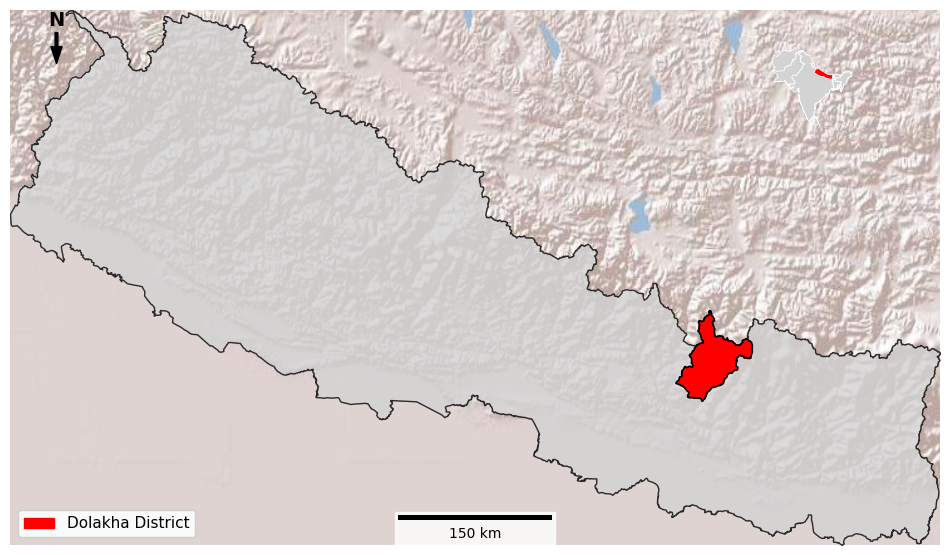

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx

from matplotlib.patches import Patch
from matplotlib_scalebar.scalebar import ScaleBar
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# ======================================
# LOAD COUNTRY DATA
# ======================================

world = gpd.read_file(
    "/content/ne_10m_admin_0_countries_nep.shp"
)

nepal =  gpd.read_file(
    "/content/1_NepalBoundary.shp"
)

# ======================================
# LOAD DISTRICTS
# ======================================

districts = gpd.read_file(
    "/content/gadm41_NPL_3.shp"
)

# ======================================
# SELECT DOLAKHA
# ======================================

dolakha = districts[
    districts["NAME_3"] == "Dolakha"
]

# ======================================
# REPROJECT
# ======================================

world = world.to_crs(3857)
nepal = nepal.to_crs(3857)
dolakha = dolakha.to_crs(3857)

# ======================================
# FIGURE
# ======================================

fig, ax = plt.subplots(
    figsize=(12,10)
)

# ======================================
# NEPAL
# ======================================

nepal.plot(
    ax=ax,
    color="lightgray",
    edgecolor="black",
    linewidth=1.0,
    alpha=0.8,
    zorder=5
)

# ======================================
# DOLAKHA HIGHLIGHT
# ======================================

dolakha.plot(
    ax=ax,
    color="red",
    edgecolor="black",
    linewidth=1.2,
    zorder=20
)

# ======================================
# BASEMAP
# ======================================

ctx.add_basemap(
    ax,
    source=ctx.providers.Esri.WorldShadedRelief,
    zoom=7,
    attribution=""
)

# ======================================
# EXTENT
# ======================================

bounds = nepal.total_bounds

ax.set_xlim(bounds[0], bounds[2])
ax.set_ylim(bounds[1], bounds[3])

# ======================================
# NORTH ARROW
# ======================================

ax.annotate(
    "N",
    xy=(0.05,0.90),
    xytext=(0.05,0.97),

    arrowprops=dict(
        facecolor="black",
        width=2,
        headwidth=8
    ),

    xycoords="axes fraction",

    ha="center",
    fontsize=14,
    fontweight="bold"
)

# ======================================
# SCALE BAR
# ======================================

scalebar = ScaleBar(
    1,
    units="m",
    dimension="si-length",
    location="lower center",
    frameon=True,
    color="black",
    box_alpha=0.8
)

ax.add_artist(scalebar)

# ======================================
# SOUTH ASIA INSET
# ======================================

axins = inset_axes(
    ax,

    width="40%",
    height="40%",

    loc="upper right",

    bbox_to_anchor=(0.55,0.55,0.4,0.4),

    bbox_transform=ax.transAxes
)

south_asia_list = [
    "Nepal",
    "India",
    "Bangladesh",
    "Pakistan",
    "Afghanistan",
    "Bhutan",
    "Sri Lanka"
]

south_asia = world[
    world["NAME"].isin(south_asia_list)
]

south_asia.plot(
    ax=axins,
    color="lightgray",
    edgecolor="white",
    linewidth=0.5
)

nepal.plot(
    ax=axins,
    color="red"
)

axins.axis("off")

# ======================================
# LEGEND
# ======================================

legend_handles = [

    Patch(
        color="red",
        label="Dolakha District"
    )
]

ax.legend(
    handles=legend_handles,

    loc="lower left",

    frameon=True,

    fontsize=11,

    facecolor="white",

    framealpha=0.9
)

# ======================================
# TITLE
# ======================================


ax.axis("off")

# ======================================
# SAVE
# ======================================

plt.savefig(
    "/content/Figure1_Dolakha_StudyArea.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()